In [162]:
!pip install Bio

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from scipy.stats import chi2
import seaborn as sns
import requests
import os
from scipy.stats import chi2

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [39]:
# Реализуем первую часть - PWM. Для начала запишем все начальные данные и посмотрим на последовательности
sites = [
    "GAGGTAAAC",
    "TCCGTAAGC",
    "CAGGTTGGA",
    "ACAGTCAGC",
    "TAGGTCAGC",
    "CAGGTCAGC",
    "CAGGTCGAT",
    "CAGGTCAGC",
    "CAGGCTAGC",
    "CAGGTCGCC"
]

In [164]:
print("Длины последовательностей:", [len(s) for s in sites])
print("\nВыравненные сайты:")
for i, s in enumerate(sites):
    print(f"{i+1:2d}: {s}")

Длины последовательностей: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]

Выравненные сайты:
 1: GAGGTAAAC
 2: TCCGTAAGC
 3: CAGGTTGGA
 4: ACAGTCAGC
 5: TAGGTCAGC
 6: CAGGTCAGC
 7: CAGGTCGAT
 8: CAGGTCAGC
 9: CAGGCTAGC
10: CAGGTCGCC


In [165]:
def create_pfm(sites, nucleotides=['A', 'C', 'G', 'T']):
    """
    Создаем PFM из списка последовательностей
    """
    n_pos = len(sites[0])
    n_nuc = len(nucleotides)
    pfm = np.zeros((n_nuc, n_pos), dtype=int)
    nuc_to_idx = {nuc: i for i, nuc in enumerate(nucleotides)}

    for site in sites:
        for pos, nuc in enumerate(site):
            if nuc in nuc_to_idx:
                pfm[nuc_to_idx[nuc], pos] += 1
    return pfm, nucleotides

In [166]:
def pfm_to_ppm(pfm, alpha=0, nucleotides=None):
    """Преобразуем PFM в PPM с псевдосчетом"""
    ppm = pfm.copy().astype(float)
    if alpha > 0:
        ppm += alpha
    col_sums = ppm.sum(axis=0)
    ppm = ppm / col_sums
    return ppm

In [167]:
def ppm_to_pwm(ppm, background):
    """Преобразуем PPM в PWM"""
    pwm = np.zeros_like(ppm)
    for i, nuc in enumerate(nucleotides):
        bg = background[nuc]
        pwm[i] = np.log2(ppm[i] / bg)
    return pwm

In [168]:
def calculate_score(pwm, sequence, nucleotides):
    """Вычисляем скор последовательности по PWM"""
    score = 0
    nuc_to_idx = {nuc: i for i, nuc in enumerate(nucleotides)}
    for pos, nuc in enumerate(sequence):
        if nuc in nuc_to_idx:
            score += pwm[nuc_to_idx[nuc], pos]
    return score

In [169]:
def find_min_max_scores(pwm, nucleotides):
    """Находим минимальный и максимальный теоретически возможные скоры"""
    max_score = 0
    min_score = 0
    max_seq = []
    min_seq = []

    for pos in range(pwm.shape[1]):
        col = pwm[:, pos]
        max_idx = np.argmax(col)
        min_idx = np.argmin(col)
        max_score += col[max_idx]
        min_score += col[min_idx]
        max_seq.append(nucleotides[max_idx])
        min_seq.append(nucleotides[min_idx])

    return max_score, ''.join(max_seq), min_score, ''.join(min_seq)

In [170]:
nucleotides = ['A', 'C', 'G', 'T']
background = {'A': 0.295, 'T': 0.295, 'G': 0.205, 'C': 0.205}

In [171]:
pfm, nuc_list = create_pfm(sites, nucleotides)
print("  " + " ".join(f"Pos{i+1}" for i in range(pfm.shape[1])))
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{pfm[i,j]:2d}" for j in range(pfm.shape[1])))

  Pos1 Pos2 Pos3 Pos4 Pos5 Pos6 Pos7 Pos8 Pos9
A:  1  8  1  0  0  2  7  2  1
C:  6  2  1  0  1  6  0  1  8
G:  1  0  8 10  0  0  3  7  0
T:  2  0  0  0  9  2  0  0  1


In [172]:
ppm = pfm_to_ppm(pfm, alpha=0.1)
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{ppm[i,j]:.3f}" for j in range(ppm.shape[1])))

A: 0.106 0.779 0.106 0.010 0.010 0.202 0.683 0.202 0.106
C: 0.587 0.202 0.106 0.010 0.106 0.587 0.010 0.106 0.779
G: 0.106 0.010 0.779 0.971 0.010 0.010 0.298 0.683 0.010
T: 0.202 0.010 0.010 0.010 0.875 0.202 0.010 0.010 0.106


In [173]:
pwm = ppm_to_pwm(ppm, background)
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{pwm[i,j]:.3f}" for j in range(pwm.shape[1])))


A: -1.480 1.401 -1.480 -4.939 -4.939 -0.547 1.211 -0.547 -1.480
C: 1.517 -0.022 -0.955 -4.414 -0.955 1.517 -4.414 -0.955 1.926
G: -0.955 -4.414 1.926 2.244 -4.414 -4.414 0.540 1.736 -4.414
T: -0.547 -4.939 -4.939 -4.939 1.569 -0.547 -4.939 -4.939 -1.480


In [174]:
max_score, max_seq, min_score, min_seq = find_min_max_scores(pwm, nucleotides)
print(f"Максимальный скор: {max_score:.3f}")
print(f"Последовательность, дающая максимум: {max_seq}")
print(f"Минимальный скор: {min_score:.3f}")
print(f"Последовательность, дающая минимум: {min_seq}")

Максимальный скор: 15.044
Последовательность, дающая максимум: CAGGTCAGC
Минимальный скор: -39.943
Последовательность, дающая минимум: ATTAAGTTG


In [175]:
# Далее приступим ко второму заданию. Честно говоря, самостоятельно реализовать импортирование хромосомы не получилось, потому был использован Дипсик. Также для записи в текстовый файл
def create_motif_from_sites(sites):
    seqs = [Seq(site) for site in sites]
    return motifs.create(seqs)

In [176]:
motif = create_motif_from_sites(sites)

In [177]:
print(f"Длина мотива: {motif.length}")
print(f"Консенсусная последовательность: {motif.consensus}")
print(f"Количество последовательностей: {len(sites)}")
print(f"\nPWM матрица (первые 3 позиции):")
pwm = motif.pwm
for nuc in ['A', 'C', 'G', 'T']:
    print(f"{nuc}: " + " ".join([f"{pwm[nuc, i]:.3f}" for i in range(min(3, motif.length))]))

Длина мотива: 9
Консенсусная последовательность: CAGGTCAGC
Количество последовательностей: 10

PWM матрица (первые 3 позиции):
A: 0.100 0.800 0.100
C: 0.600 0.200 0.100
G: 0.100 0.000 0.800
T: 0.200 0.000 0.000


In [178]:
# Функция для загрузки хромосомы из FASTA файла
def load_chromosome_from_file(filename="chr1.fa", n_bases=1000000):
    """
    Загружаем последовательность хромосомы из FASTA файла с помощью SeqIO.parse
    """
    # Проверяем существование файла
    if not os.path.exists(filename):
        print(f"ВНИМАНИЕ: Файл {filename} не найден!")
        print("Создаем тестовую последовательность с частотами генома человека...")

        # Генерируем тестовую последовательность
        np.random.seed(42)
        frequencies = {'A': 0.295, 'T': 0.295, 'G': 0.205, 'C': 0.205}
        nucleotides = list(frequencies.keys())
        probs = list(frequencies.values())
        test_seq = ''.join(np.random.choice(nucleotides, size=n_bases, p=probs))
        print(f"Создана тестовая последовательность длиной {len(test_seq):,} нуклеотидов")
        return test_seq

    # Используем SeqIO.parse для чтения FASTA файла
    with open(filename, 'r') as handle:
        records = list(SeqIO.parse(handle, "fasta"))

        if len(records) == 0:
            raise ValueError(f"В файле {filename} нет записей")

        record = records[0]
        print(f"ID записи: {record.id}")
        print(f"Длина полной хромосомы: {len(record.seq):,} нуклеотидов")

        # Извлекаем первые n_bases нуклеотидов
        sequence = str(record.seq)[:n_bases]
        print(f"Извлечено {len(sequence):,} нуклеотидов для анализа")
        print(f"Первые 100 нуклеотидов: {sequence[:100]}...")

        return sequence

In [179]:
def scan_sequence_with_pwm(motif, sequence, threshold=5.0):
    pwm = motif.pwm
    L = motif.length

    nucleotides = ['A', 'C', 'G', 'T']
    pwm_array = np.zeros((4, L))
    for i, nuc in enumerate(nucleotides):
        for j in range(L):
            pwm_array[i, j] = pwm[nuc, j]

    nuc_to_idx = {nuc: i for i, nuc in enumerate(nucleotides)}

    hits_forward = []
    for i in range(len(sequence) - L + 1):
        window = sequence[i:i+L]
        score = 0
        valid = True
        for pos, nuc in enumerate(window):
            if nuc in nuc_to_idx:
                score += pwm_array[nuc_to_idx[nuc], pos]
            else:
                valid = False
                break
        if valid and score > threshold:
            hits_forward.append((i, '+', score))

    reverse_seq = str(Seq(sequence).reverse_complement())
    hits_reverse = []
    for i in range(len(reverse_seq) - L + 1):
        window = reverse_seq[i:i+L]
        score = 0
        valid = True
        for pos, nuc in enumerate(window):
            if nuc in nuc_to_idx:
                score += pwm_array[nuc_to_idx[nuc], pos]
            else:
                valid = False
                break
        if valid and score > threshold:
            orig_position = len(sequence) - i - L
            hits_reverse.append((orig_position, '-', score))

    return hits_forward, hits_reverse

In [180]:
# Загружаем хромосому 1
chr1_sequence = load_chromosome_from_file("chr1.fa", 1000000)

print(f"Длина: {len(chr1_sequence):,} нуклеотидов")
print(f"Состав: A={chr1_sequence.count('A')/len(chr1_sequence):.2%}")
print(f"        C={chr1_sequence.count('C')/len(chr1_sequence):.2%}")
print(f"        G={chr1_sequence.count('G')/len(chr1_sequence):.2%}")
print(f"        T={chr1_sequence.count('T')/len(chr1_sequence):.2%}")

ВНИМАНИЕ: Файл chr1.fa не найден!
Создаем тестовую последовательность с частотами генома человека...
Создана тестовая последовательность длиной 1,000,000 нуклеотидов
Длина: 1,000,000 нуклеотидов
Состав: A=29.45%
        C=20.53%
        G=20.52%
        T=29.50%


In [181]:
# Поиск сайтов связывания с порогом > 5.0
print(f"Длина мотива: {motif.length}")
print(f"Длина последовательности: {len(chr1_sequence):,}")

hits_forward, hits_reverse = scan_sequence_with_pwm(motif, chr1_sequence, threshold=5.0)

print(f"Прямая цепь (+): {len(hits_forward)} хитов")
print(f"Обратная цепь (-): {len(hits_reverse)} хитов")
print(f"Всего: {len(hits_forward) + len(hits_reverse)} хитов")

Длина мотива: 9
Длина последовательности: 1,000,000
Прямая цепь (+): 2429 хитов
Обратная цепь (-): 2478 хитов
Всего: 4907 хитов


In [182]:
# Выводим первые 20 хитов для каждой цепи
print(f"{'№':<4} {'Позиция':<12} {'Скор':<10} {'Последовательность':<12} {'Контекст':<35}")
for i, (pos, strand, score) in enumerate(hits_forward[:20]):
    site_seq = chr1_sequence[pos:pos+motif.length]
    start = max(0, pos-10)
    end = min(len(chr1_sequence), pos+motif.length+10)
    context = chr1_sequence[start:end]
    context = "..." + context + "..."
    print(f"{i+1:<4} {pos:<12} {score:<10.3f} {site_seq:<12} {context:<35}")


print(f"{'№':<4} {'Позиция':<12} {'Скор':<10}")
for i, (pos, strand, score) in enumerate(hits_reverse[:20]):
    print(f"{i+1:<4} {pos:<12} {score:<10.3f}")

№    Позиция      Скор       Последовательность Контекст                           
1    459          5.200      AAGGTCTAC    ...AGTTCATATAAAGGTCTACACACACTCAT...
2    1325         5.200      TAGGTTGAC    ...GTGAAAACACTAGGTTGACCGAGAAATCG...
3    1439         5.100      GCAGTCAGC    ...CTTTGAATGAGCAGTCAGCCGTGCTACGG...
4    1591         5.300      CAAGTAAAC    ...TGTCAGTTGGCAAGTAAACATATATACAT...
5    2012         5.100      CATTTCAGC    ...CAAGTGATAACATTTCAGCTCATAGCAGA...
6    2101         5.300      TAGGTCCAC    ...CATAGTGCTCTAGGTCCACAAACGATGAC...
7    2175         5.300      CAGGTTAAT    ...CGAGTGAACACAGGTTAATGCCGGGACGT...
8    2343         5.300      TCGGTGAGC    ...GATTTATGAATCGGTGAGCGCGACATAAT...
9    2661         5.400      CAGGTAGGT    ...TTAGTCCAGTCAGGTAGGTGTGACATAAT...
10   2949         5.900      CCGGTCGGC    ...AAGTGGATTTCCGGTCGGCACATTCCGGT...
11   3067         5.600      CAGGGTAGC    ...AACTAGGGAACAGGGTAGCCAACGCATGG...
12   4080         5.100      GAGGAAAGC    ...TGGGGTTAGAGAG

In [183]:
# Сохраняем все хиты в текстовый файл
def save_hits_to_file(hits_forward, hits_reverse, filename="binding_sites_hits.txt"):
    with open(filename, 'w') as f:
        f.write("# Результаты поиска сайтов связывания\n")
        f.write("# Порог скора: 5.0\n")
        f.write("# Формат: позиция, цепь, скор\n")
        f.write("-"*40 + "\n")
        f.write("Позиция\tЦепь\tСкор\n")

        for pos, strand, score in hits_forward:
            f.write(f"{pos}\t{strand}\t{score:.3f}\n")

        for pos, strand, score in hits_reverse:
            f.write(f"{pos}\t{strand}\t{score:.3f}\n")

    return filename

# Сохраняем результаты
output_file = save_hits_to_file(hits_forward, hits_reverse, "binding_sites_hits.txt")
print(f"Результаты сохранены в файл: {output_file}")
print(f"Всего записей: {len(hits_forward) + len(hits_reverse)}")

Результаты сохранены в файл: binding_sites_hits.txt
Всего записей: 4907


In [185]:
if hits_forward:
    scores_f = [s for _, _, s in hits_forward]
    print(f"\nПрямая цепь:")
    print(f"  Минимальный скор: {min(scores_f):.3f}")
    print(f"  Максимальный скор: {max(scores_f):.3f}")
    print(f"  Средний скор: {np.mean(scores_f):.3f}")
    print(f"  Медианный скор: {np.median(scores_f):.3f}")
    print(f"  Стандартное отклонение: {np.std(scores_f):.3f}")

if hits_reverse:
    scores_r = [s for _, _, s in hits_reverse]
    print(f"\nОбратная цепь:")
    print(f"  Минимальный скор: {min(scores_r):.3f}")
    print(f"  Максимальный скор: {max(scores_r):.3f}")
    print(f"  Средний скор: {np.mean(scores_r):.3f}")
    print(f"  Медианный скор: {np.median(scores_r):.3f}")
    print(f"  Стандартное отклонение: {np.std(scores_r):.3f}")


Прямая цепь:
  Минимальный скор: 5.000
  Максимальный скор: 6.900
  Средний скор: 5.343
  Медианный скор: 5.300
  Стандартное отклонение: 0.267

Обратная цепь:
  Минимальный скор: 5.000
  Максимальный скор: 6.500
  Средний скор: 5.344
  Медианный скор: 5.300
  Стандартное отклонение: 0.270


In [187]:
# Перейдем к третьему заданию, сгенерируем последовательности, а затем подсчитаем p-value
def generate_background_sequences(n_seqs, length, frequencies):
    nucleotides = list(frequencies.keys())
    probs = list(frequencies.values())
    sequences = []
    for _ in range(n_seqs):
        seq = ''.join(np.random.choice(nucleotides, size=length, p=probs))
        sequences.append(seq)
    return sequences

In [188]:
def get_p_value(score, background_scores):
    return np.mean(np.array(background_scores) >= score)

In [189]:
np.random.seed(42)
background_freq = {'A': 0.295, 'T': 0.295, 'G': 0.205, 'C': 0.205}
background_seqs = generate_background_sequences(100000, 9, background_freq)

In [190]:
background_scores = []
for seq in background_seqs:
    score = calculate_score(pwm, seq, nucleotides)
    background_scores.append(score)

background_scores = np.array(background_scores)

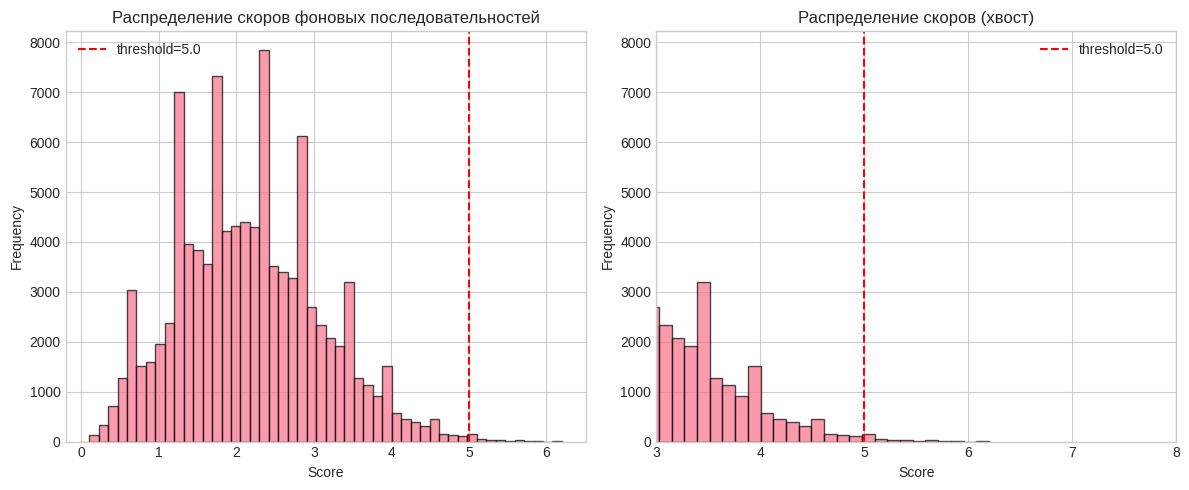

In [191]:
# Визуализируем результаты распределения
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(background_scores, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Распределение скоров фоновых последовательностей')
plt.axvline(x=5.0, color='red', linestyle='--', label='threshold=5.0')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(background_scores, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Распределение скоров (хвост)')
plt.xlim([3, 8])
plt.axvline(x=5.0, color='red', linestyle='--', label='threshold=5.0')
plt.legend()

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()

In [192]:
sorted_scores = np.sort(background_scores)
target_pvalue = 1e-4
n_seqs = len(background_scores)
threshold_idx = int(n_seqs * (1 - target_pvalue))
if threshold_idx < n_seqs:
    threshold_pvalue = sorted_scores[threshold_idx]
else:
    threshold_pvalue = sorted_scores[-1]

In [193]:
print(f"Средний скор: {np.mean(background_scores):.3f}")
print(f"Медианный скор: {np.median(background_scores):.3f}")
print(f"Стандартное отклонение: {np.std(background_scores):.3f}")
print(f"Максимальный скор: {np.max(background_scores):.3f}")
print(f"Минимальный скор: {np.min(background_scores):.3f}")

Средний скор: 2.171
Медианный скор: 2.100
Стандартное отклонение: 0.923
Максимальный скор: 6.200
Минимальный скор: 0.100


In [194]:
for score_threshold in [4.0, 5.0, 6.0, 7.0]:
    pval = get_p_value(score_threshold, background_scores)
    print(f"Score >= {score_threshold}: p-value = {pval:.6f}")

Score >= 4.0: p-value = 0.035920
Score >= 5.0: p-value = 0.003310
Score >= 6.0: p-value = 0.000040
Score >= 7.0: p-value = 0.000000


In [195]:
print(f"Порог для p-value ≈ {target_pvalue:.0e}")
print(f"Необходимый порог: {threshold_pvalue:.3f}")

Порог для p-value ≈ 1e-04
Необходимый порог: 5.800


In [196]:
# Посмотрим на информационное содержание мотива
def calculate_shannon_entropy(ppm):
    H = np.zeros(ppm.shape[1])
    for i in range(ppm.shape[1]):
        col = ppm[:, i]
        non_zero = col[col > 0]
        H[i] = -np.sum(non_zero * np.log2(non_zero))
    return H

In [197]:
def calculate_information_content(ppm, max_entropy=2):
    H = calculate_shannon_entropy(ppm)
    return max_entropy - H

In [198]:
ppm_no_pseudocount = pfm_to_ppm(pfm, alpha=0)

H = calculate_shannon_entropy(ppm_no_pseudocount)
IC = calculate_information_content(ppm_no_pseudocount)

In [199]:
for i, h in enumerate(H):
    print(f"Позиция {i+1}: {h:.3f} бит")

Позиция 1: 1.571 бит
Позиция 2: 0.722 бит
Позиция 3: 0.922 бит
Позиция 4: -0.000 бит
Позиция 5: 0.469 бит
Позиция 6: 1.371 бит
Позиция 7: 0.881 бит
Позиция 8: 1.157 бит
Позиция 9: 0.922 бит


In [200]:
for i, ic in enumerate(IC):
    print(f"Позиция {i+1}: {ic:.3f} бит")

Позиция 1: 0.429 бит
Позиция 2: 1.278 бит
Позиция 3: 1.078 бит
Позиция 4: 2.000 бит
Позиция 5: 1.531 бит
Позиция 6: 0.629 бит
Позиция 7: 1.119 бит
Позиция 8: 0.843 бит
Позиция 9: 1.078 бит


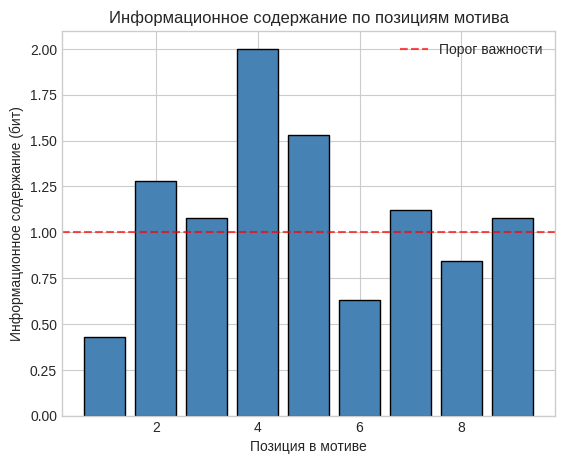

In [201]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(range(1, len(IC)+1), IC, color='steelblue', edgecolor='black')
plt.xlabel('Позиция в мотиве')
plt.ylabel('Информационное содержание (бит)')
plt.title('Информационное содержание по позициям мотива')
plt.ylim(0, 2.1)
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Порог важности')
plt.legend()

/tmp/ipykernel_14381/2373036289.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


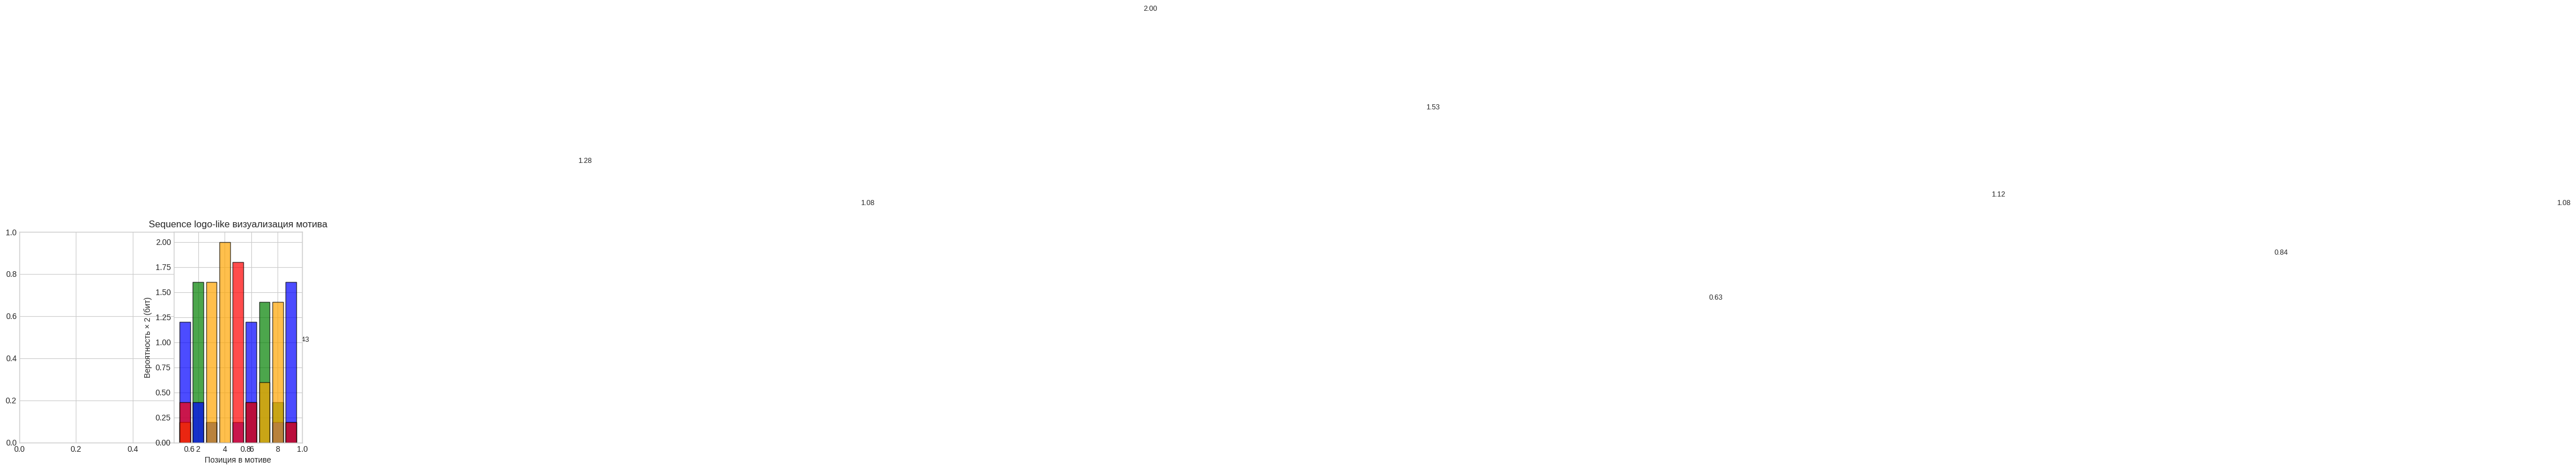

In [202]:
for i, ic in enumerate(IC):
    plt.text(i+1, ic + 0.05, f'{ic:.2f}', ha='center', fontsize=9)

plt.subplot(1, 2, 2)

positions = []
nuc_names = []
heights = []
for pos in range(ppm_no_pseudocount.shape[1]):
    for nuc_idx, nuc in enumerate(nucleotides):
        if ppm_no_pseudocount[nuc_idx, pos] > 0:
            positions.append(pos + 1)
            nuc_names.append(nuc)
            heights.append(ppm_no_pseudocount[nuc_idx, pos] * 2)

colors = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
bar_colors = [colors[nuc] for nuc in nuc_names]

plt.bar(positions, heights, color=bar_colors, edgecolor='black', alpha=0.7)
plt.xlabel('Позиция в мотиве')
plt.ylabel('Вероятность × 2 (бит)')
plt.title('Sequence logo-like визуализация мотива')
plt.ylim(0, 2.1)

plt.tight_layout()
plt.savefig('information_content.png', dpi=150)
plt.show()

In [203]:
core_threshold = 1.0
core_positions = [i+1 for i, ic in enumerate(IC) if ic >= core_threshold]
variable_positions = [i+1 for i, ic in enumerate(IC) if ic < core_threshold]

In [204]:
print(f"Core-мотив (IC >= {core_threshold}): позиции {core_positions}")
print(f"Вариабельные позиции: позиции {variable_positions}")

Core-мотив (IC >= 1.0): позиции [2, 3, 4, 5, 7, 9]
Вариабельные позиции: позиции [1, 6, 8]


In [205]:
print("  " + "".join(f"{i+1:4d}" for i in range(9)))
for i, site in enumerate(sites):
    print(f"{i+1:2d}: " + " ".join(site))

     1   2   3   4   5   6   7   8   9
 1: G A G G T A A A C
 2: T C C G T A A G C
 3: C A G G T T G G A
 4: A C A G T C A G C
 5: T A G G T C A G C
 6: C A G G T C A G C
 7: C A G G T C G A T
 8: C A G G T C A G C
 9: C A G G C T A G C
10: C A G G T C G C C


In [206]:
# Перейдем ко второй части задания - но будем производить все действия со сгенерированными последовательностями
def get_dna_sequence(length=10000, random_seed=42):
    """Генерируем ДНК последовательность с частотами генома человека"""
    np.random.seed(random_seed)
    frequencies = {'A': 0.295, 'T': 0.295, 'G': 0.205, 'C': 0.205}
    nucleotides = list(frequencies.keys())
    probs = list(frequencies.values())
    sequence = ''.join(np.random.choice(nucleotides, size=length, p=probs))
    return sequence

In [207]:
seq = get_dna_sequence(10000)
print(f"Длина: {len(seq)} нуклеотидов")
print(f"Первые 100 нуклеотидов: {seq[:100]}...")
print(f"\nСостав последовательности:")
for nuc in ['A', 'C', 'G', 'T']:
    freq = seq.count(nuc) / len(seq)
    print(f"  {nuc}: {freq:.4f}")

Длина: 10000 нуклеотидов
Первые 100 нуклеотидов: TCGGAAACGGACCAAATTTAGAATTGATGAGAACCCTAGTATACAGTTTACGCCGCAAATTACTATACACGAACGGGATACGTATTGGCTAGGTGTTTAA...

Состав последовательности:
  A: 0.3003
  C: 0.2008
  G: 0.1990
  T: 0.2999


In [208]:
def count_dinucleotides(sequence):
    """Подсчитываем частоты всех 16 динуклеотидов"""
    nucleotides = ['A', 'C', 'G', 'T']
    counts = {n1+n2: 0 for n1 in nucleotides for n2 in nucleotides}

    for i in range(len(sequence) - 1):
        dinuc = sequence[i:i+2]
        if dinuc in counts:
            counts[dinuc] += 1
    return counts

In [210]:
def build_transition_matrix(sequence):
    """Строим матрицу переходов 4x4 с нормализацией по строкам"""
    nucleotides = ['A', 'C', 'G', 'T']
    nuc_to_idx = {nuc: i for i, nuc in enumerate(nucleotides)}

    transitions = np.zeros((4, 4))
    for i in range(len(sequence) - 1):
        from_nuc = sequence[i]
        to_nuc = sequence[i+1]
        if from_nuc in nuc_to_idx and to_nuc in nuc_to_idx:
            transitions[nuc_to_idx[from_nuc], nuc_to_idx[to_nuc]] += 1

    row_sums = transitions.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    transition_matrix = transitions / row_sums

    return transition_matrix, nucleotides

In [211]:
dinuc_counts = count_dinucleotides(seq)
print("Полученные частоты динуклеотидов")
for dinuc, count in dinuc_counts.items():
    print(f"{dinuc}: {count:5d}")

Полученные частоты динуклеотидов
AA:   886
AC:   619
AG:   593
AT:   904
CA:   619
CC:   422
CG:   371
CT:   596
GA:   628
GC:   365
GG:   411
GT:   586
TA:   870
TC:   602
TG:   615
TT:   912


In [214]:
# Явно построим матрицу переходов, ну и проверим что по всем строкам суммы равны единицам
P, nucleotides = build_transition_matrix(seq)
print("        A       C       G       T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{P[i,j]:8.4f}" for j in range(4)))


        A       C       G       T
A:   0.2951   0.2062   0.1975   0.3011
C:   0.3083   0.2102   0.1848   0.2968
G:   0.3156   0.1834   0.2065   0.2945
T:   0.2901   0.2007   0.2051   0.3041


In [215]:
for i, nuc in enumerate(nucleotides):
    row_sum = P[i].sum()
    print(f"Строка {nuc}: сумма = {row_sum:.6f}")

Строка A: сумма = 1.000000
Строка C: сумма = 1.000000
Строка G: сумма = 1.000000
Строка T: сумма = 1.000000


In [216]:
def get_stationary_distribution(P):
    """
    Находим стационарное распределение
    Фактически решается система:
    π = πP, sum(π) = 1
    π(I - P) = 0
    """
    n = P.shape[0]
    A = np.eye(n) - P.T
    A[-1] = np.ones(n)
    b = np.zeros(n)
    b[-1] = 1
    pi = np.linalg.solve(A, b)
    return pi

In [217]:
def get_observed_frequencies(sequence):
    """Вычисляем частоты нуклеотидов"""
    nucleotides = ['A', 'C', 'G', 'T']
    counts = {nuc: sequence.count(nuc) for nuc in nucleotides}
    total = sum(counts.values())
    return {nuc: counts[nuc]/total for nuc in nucleotides}

In [218]:
# Получим стационарное распределение
stationary = get_stationary_distribution(P)
for nuc, prob in zip(nucleotides, stationary):
    print(f"π({nuc}) = {prob:.6f}")

π(A) = 0.300331
π(C) = 0.200821
π(G) = 0.199019
π(T) = 0.299830


In [219]:
# И частоты нуклеотидов
observed_freq = get_observed_frequencies(seq)
for nuc in nucleotides:
    print(f"P({nuc}) = {observed_freq[nuc]:.6f}")

P(A) = 0.300300
P(C) = 0.200800
P(G) = 0.199000
P(T) = 0.299900


In [221]:
# Явно подсчитаем разницу между стационарным и наблюдаемым распределением
print("Нуклеотид | Стационарное | Наблюдаемое | Разница")
for i, nuc in enumerate(nucleotides):
    diff = stationary[i] - observed_freq[nuc]
    print(f"   {nuc}     |   {stationary[i]:.6f}   |   {observed_freq[nuc]:.6f}   |  {diff:+.6f}")

Нуклеотид | Стационарное | Наблюдаемое | Разница
   A     |   0.300331   |   0.300300   |  +0.000031
   C     |   0.200821   |   0.200800   |  +0.000021
   G     |   0.199019   |   0.199000   |  +0.000019
   T     |   0.299830   |   0.299900   |  -0.000070


In [222]:
def analyze_convergence(P, max_k=100):
    """Анализируем сходимость степеней матрицы"""
    norms = []
    power_matrices = {}
    P_prev = P.copy()

    for k in range(1, max_k + 1):
        P_k = np.linalg.matrix_power(P, k)

        if k in [1, 2, 5, 10, 20, 50, 100]:
            power_matrices[k] = P_k

        norm_diff = np.linalg.norm(P_k - P_prev, 'fro')
        norms.append(norm_diff)
        P_prev = P_k

    return norms, power_matrices

In [223]:
max_k = 100
norms, power_matrices = analyze_convergence(P, max_k)

In [224]:
for k in [1, 5, 10, 20, 50]:
    if k in power_matrices:
        print(f"\nP^{k}:")
        print("        A       C       G       T")
        for i, nuc in enumerate(nucleotides):
            row = power_matrices[k][i]
            print(f"{nuc}: " + " ".join(f"{val:.6f}" for val in row))


P^1:
        A       C       G       T
A: 0.295137 0.206196 0.197535 0.301133
C: 0.308267 0.210159 0.184761 0.296813
G: 0.315578 0.183417 0.206533 0.294472
T: 0.290097 0.200734 0.205068 0.304101

P^5:
        A       C       G       T
A: 0.300331 0.200821 0.199019 0.299830
C: 0.300331 0.200821 0.199019 0.299830
G: 0.300331 0.200821 0.199019 0.299830
T: 0.300331 0.200821 0.199019 0.299830

P^10:
        A       C       G       T
A: 0.300331 0.200821 0.199019 0.299830
C: 0.300331 0.200821 0.199019 0.299830
G: 0.300331 0.200821 0.199019 0.299830
T: 0.300331 0.200821 0.199019 0.299830

P^20:
        A       C       G       T
A: 0.300331 0.200821 0.199019 0.299830
C: 0.300331 0.200821 0.199019 0.299830
G: 0.300331 0.200821 0.199019 0.299830
T: 0.300331 0.200821 0.199019 0.299830

P^50:
        A       C       G       T
A: 0.300331 0.200821 0.199019 0.299830
C: 0.300331 0.200821 0.199019 0.299830
G: 0.300331 0.200821 0.199019 0.299830
T: 0.300331 0.200821 0.199019 0.299830


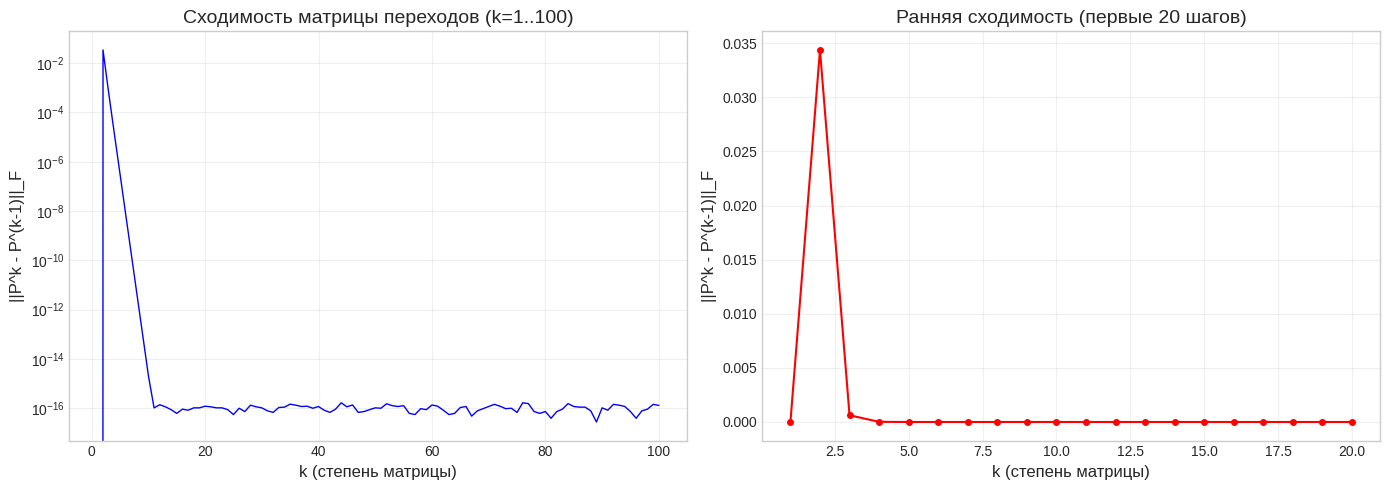

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(norms)+1), norms, 'b-', linewidth=1)
axes[0].set_xlabel('k (степень матрицы)', fontsize=12)
axes[0].set_ylabel('||P^k - P^(k-1)||_F', fontsize=12)
axes[0].set_title('Сходимость матрицы переходов (k=1..100)', fontsize=14)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, min(21, len(norms)+1)), norms[:20], 'r-o', linewidth=1.5, markersize=4)
axes[1].set_xlabel('k (степень матрицы)', fontsize=12)
axes[1].set_ylabel('||P^k - P^(k-1)||_F', fontsize=12)
axes[1].set_title('Ранняя сходимость (первые 20 шагов)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150)
plt.show()

In [226]:
# Проверим сходимость к стационарному распределению
P_100 = power_matrices[100]
print("Стационарное распределение π:", [f"{x:.6f}" for x in stationary])
print("\nСтроки P^100:")
for i, nuc in enumerate(nucleotides):
    print(f"Строка {nuc}: " + " ".join(f"{P_100[i,j]:.6f}" for j in range(4)))
    max_diff = np.max(np.abs(P_100[i] - stationary))
    print(f"  Макс. отклонение от π: {max_diff:.6e}")

Стационарное распределение π: ['0.300331', '0.200821', '0.199019', '0.299830']

Строки P^100:
Строка A: 0.300331 0.200821 0.199019 0.299830
  Макс. отклонение от π: 2.220446e-16
Строка C: 0.300331 0.200821 0.199019 0.299830
  Макс. отклонение от π: 2.220446e-16
Строка G: 0.300331 0.200821 0.199019 0.299830
  Макс. отклонение от π: 1.665335e-16
Строка T: 0.300331 0.200821 0.199019 0.299830
  Макс. отклонение от π: 1.942890e-16


In [227]:
chr1_seq = get_dna_sequence(100000, random_seed=42)

In [233]:
def compute_cpg_ratio(window):
    """
    Вычисляем для окна(которым проходим по всей последовательности):
    P(CG) - частоты динуклеотида CG
    P(C) и P(G) - частоты отдельных нуклеотидов
    R(CG) = P(CG) / (P(C) * P(G))
    GC% - процент G и C
    """
    if len(window) < 2:
        return 0, 0, 0, 0, 0

    n_C = window.count('C')
    n_G = window.count('G')
    n_total = len(window)

    P_C = n_C / n_total
    P_G = n_G / n_total
    GC_percent = (n_C + n_G) / n_total * 100

    n_CG = sum(1 for i in range(len(window)-1) if window[i:i+2] == 'CG')
    P_CG = n_CG / (n_total - 1)

    if P_C * P_G > 0:
        R_CG = P_CG / (P_C * P_G)
    else:
        R_CG = 0

    return P_CG, P_C, P_G, R_CG, GC_percent


In [229]:
window_size = 200
step = 50

positions = []
r_values = []
gc_values = []
cpg_islands = []

In [230]:
for i in range(0, len(chr1_seq) - window_size + 1, step):
    window = chr1_seq[i:i+window_size]
    _, _, _, R_CG, GC_percent = compute_cpg_ratio(window)

    positions.append(i + window_size//2)
    r_values.append(R_CG)
    gc_values.append(GC_percent)

    if R_CG > 0.6 and GC_percent > 50:
        cpg_islands.append((i, i+window_size, R_CG, GC_percent))

In [231]:
merged_islands = []
for island in cpg_islands:
    if not merged_islands or island[0] > merged_islands[-1][1]:
        merged_islands.append(list(island))
    else:
        merged_islands[-1][1] = max(merged_islands[-1][1], island[1])

In [232]:
print(f"Размер окна: {window_size}")
print(f"Порог R(CG): 0.6")
print(f"Порог GC%: 50%")
print(f"\nНайдено CpG островков: {len(merged_islands)}")
for i, (start, end, r_cg, gc_pct) in enumerate(merged_islands[:10]):
    print(f"  Остров {i+1}: {start}-{end} (длина: {end-start}), R(CG)={r_cg:.3f}, GC%={gc_pct:.1f}%")

Размер окна: 200
Порог R(CG): 0.6
Порог GC%: 50%

Найдено CpG островков: 9
  Остров 1: 1000-1200 (длина: 200), R(CG)=1.014, GC%=51.0%
  Остров 2: 18600-18850 (длина: 250), R(CG)=0.775, GC%=51.0%
  Остров 3: 22750-22950 (длина: 200), R(CG)=0.757, GC%=52.0%
  Остров 4: 50450-50650 (длина: 200), R(CG)=0.912, GC%=51.5%
  Остров 5: 51350-51600 (длина: 250), R(CG)=1.262, GC%=50.5%
  Остров 6: 62400-62750 (длина: 350), R(CG)=0.730, GC%=50.5%
  Остров 7: 77250-77450 (длина: 200), R(CG)=0.950, GC%=50.5%
  Остров 8: 81500-81700 (длина: 200), R(CG)=1.026, GC%=50.5%
  Остров 9: 96250-96450 (длина: 200), R(CG)=0.945, GC%=51.0%


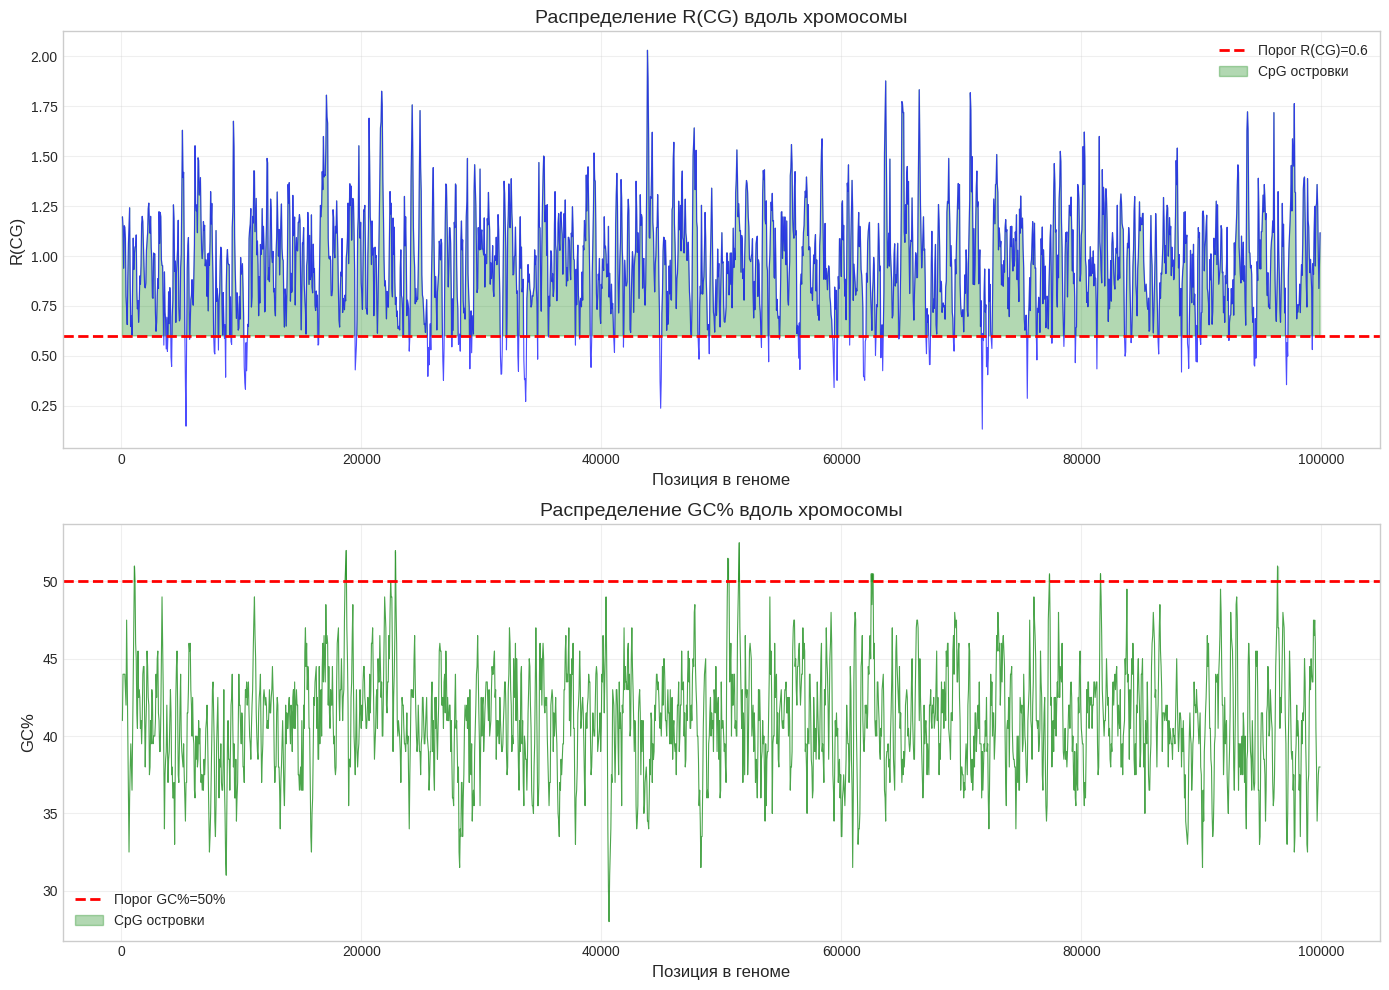

In [149]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(positions, r_values, 'b-', linewidth=0.8, alpha=0.7)
axes[0].axhline(y=0.6, color='r', linestyle='--', linewidth=2, label='Порог R(CG)=0.6')
axes[0].fill_between(positions, r_values, 0.6, where=np.array(r_values) > 0.6,
                      color='green', alpha=0.3, label='CpG островки')
axes[0].set_xlabel('Позиция в геноме', fontsize=12)
axes[0].set_ylabel('R(CG)', fontsize=12)
axes[0].set_title('Распределение R(CG) вдоль хромосомы', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(positions, gc_values, 'g-', linewidth=0.8, alpha=0.7)
axes[1].axhline(y=50, color='r', linestyle='--', linewidth=2, label='Порог GC%=50%')
axes[1].fill_between(positions, gc_values, 50, where=np.array(gc_values) > 50,
                      color='green', alpha=0.3, label='CpG островки')
axes[1].set_xlabel('Позиция в геноме', fontsize=12)
axes[1].set_ylabel('GC%', fontsize=12)
axes[1].set_title('Распределение GC% вдоль хромосомы', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cpg_islands_detector.png', dpi=150)
plt.show()

In [234]:
def generate_sequence(P, length, start_state, nucleotides=['A', 'C', 'G', 'T']):
    """
    Генерируем последовательность по марковской модели 1-го порядка
    """
    nuc_to_idx = {nuc: i for i, nuc in enumerate(nucleotides)}
    idx_to_nuc = {i: nuc for i, nuc in enumerate(nucleotides)}

    if start_state not in nuc_to_idx:
        start_state = np.random.choice(nucleotides)

    sequence = [start_state]
    current_idx = nuc_to_idx[start_state]

    for _ in range(length - 1):
        next_idx = np.random.choice(4, p=P[current_idx])
        sequence.append(idx_to_nuc[next_idx])
        current_idx = next_idx

    return ''.join(sequence)


In [235]:
np.random.seed(42)
n_sequences = 10
length = 1000
start_state = 'A'

generated_sequences = []
for i in range(n_sequences):
    seq = generate_sequence(P, length, start_state, nucleotides)
    generated_sequences.append(seq)
    print(f"Последовательность {i+1}: {seq[:50]}...")


Последовательность 1: ACTTGAAATGTATTAAACGCAGAACCTAGGAGAATTTCAGCACATAGAGG...
Последовательность 2: ACAGTTTGGTACATTATTAGTAGATTTCTTCTAGAAAGCTACGTCGTGAA...
Последовательность 3: AAAAATAATCTACAATAGCCTAGTGTACATTAGAGCTGCAAAATGGATTA...
Последовательность 4: ACATGTAGGTTAGAGACCGCTCATACGCACTGGGACTAAACTAGATACTT...
Последовательность 5: ACCGAGTTAAACCGAACGAGATTCACAGTGTCATCGAATATTTGGTACGC...
Последовательность 6: ATACTGCCTCTATTACATGGAAACGTGCTTTGAATACGGGACGTTTTGAG...
Последовательность 7: AAGGTCAGATGATGAGATTTGCTAGGACTTAAATATAGCTAGATTATGAC...
Последовательность 8: AATGGTCGAATTCCGAAAATAAGTAACTGTTTGCATCAGAGGCTACGGTC...
Последовательность 9: AACAAACTATGATGCTAGATCGAGTCGCTGTTCACTAGTCGAATAATCTT...
Последовательность 10: AACCAGATATTGTCGCAGCGACAAAAATAGATCAGCGATCCTCTCTATTA...


In [236]:
all_matrices = []
for seq in generated_sequences:
    P_seq, _ = build_transition_matrix(seq)
    all_matrices.append(P_seq)

P_empirical = np.mean(all_matrices, axis=0)

In [239]:
# Сравним исходную и экспериментальную матрицы. Эмпирическую возьмем как среднее между 10 последовательностями, посмотрим на разницу
print("Исходная матрица P:")
print("        A       C       G       T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{P[i,j]:.4f}" for j in range(4)))

print("\nЭмпирическая матрица:")
print("        A       C       G       T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{P_empirical[i,j]:.4f}" for j in range(4)))

diff = np.abs(P - P_empirical)
print(f"\nСредняя абсолютная разница: {np.mean(diff):.6f}")
print(f"Максимальная абсолютная разница: {np.max(diff):.6f}")

Исходная матрица P:
        A       C       G       T
A: 0.2951 0.2062 0.1975 0.3011
C: 0.3083 0.2102 0.1848 0.2968
G: 0.3156 0.1834 0.2065 0.2945
T: 0.2901 0.2007 0.2051 0.3041

Эмпирическая матрица:
        A       C       G       T
A: 0.2958 0.2156 0.1991 0.2896
C: 0.3017 0.2142 0.1932 0.2909
G: 0.3263 0.1864 0.2045 0.2828
T: 0.3070 0.1952 0.2101 0.2876

Средняя абсолютная разница: 0.007469
Максимальная абсолютная разница: 0.016912


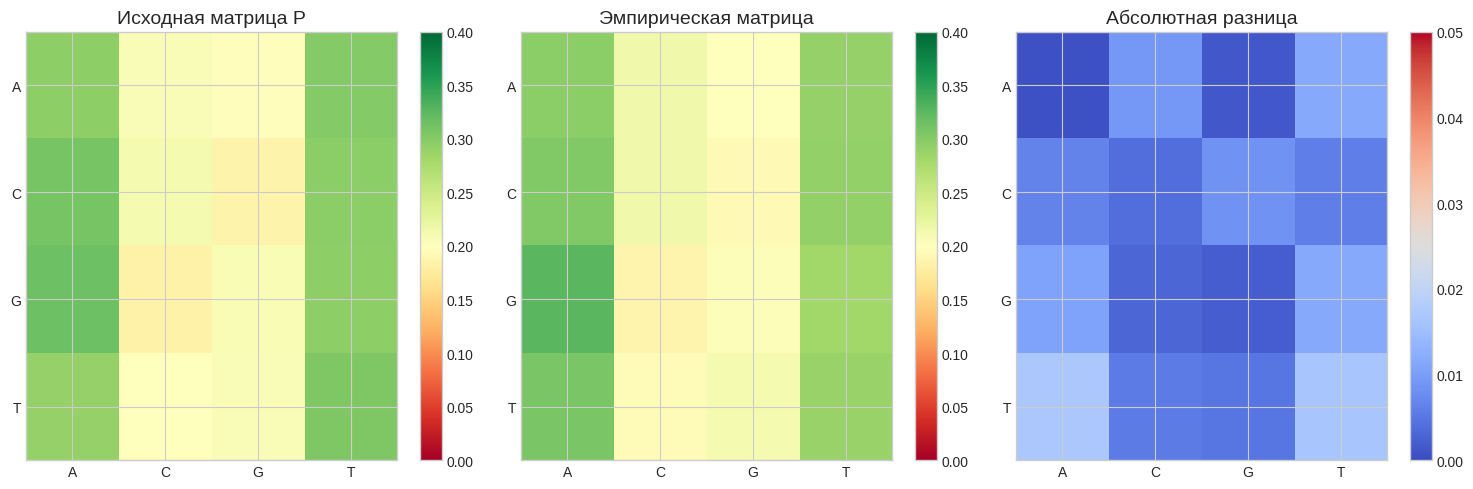

In [240]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im1 = axes[0].imshow(P, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.4)
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(nucleotides)
axes[0].set_yticklabels(nucleotides)
axes[0].set_title('Исходная матрица P', fontsize=14)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(P_empirical, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.4)
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(nucleotides)
axes[1].set_yticklabels(nucleotides)
axes[1].set_title('Эмпирическая матрица', fontsize=14)
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(diff, cmap='coolwarm', aspect='auto', vmin=0, vmax=0.05)
axes[2].set_xticks(range(4))
axes[2].set_yticks(range(4))
axes[2].set_xticklabels(nucleotides)
axes[2].set_yticklabels(nucleotides)
axes[2].set_title('Абсолютная разница', fontsize=14)
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig('markov_simulation.png', dpi=150)
plt.show()

In [241]:
def chi_square_test(sequence, background_freq=None):
    """
    Проверяем гипотезу о независимости соседних нуклеотидов с помощью хи квадрата
    """
    nucleotides = ['A', 'C', 'G', 'T']
    nuc_to_idx = {nuc: i for i, nuc in enumerate(nucleotides)}

    counts = {nuc: sequence.count(nuc) for nuc in nucleotides}
    total = len(sequence)
    P_i = {nuc: counts[nuc] / total for nuc in nucleotides}

    if background_freq is None:
        background_freq = P_i

    observed = np.zeros((4, 4))
    for i in range(len(sequence) - 1):
        from_nuc = sequence[i]
        to_nuc = sequence[i+1]
        if from_nuc in nuc_to_idx and to_nuc in nuc_to_idx:
            observed[nuc_to_idx[from_nuc], nuc_to_idx[to_nuc]] += 1

    N = len(sequence) - 1

    expected = np.zeros((4, 4))
    for i, nuc1 in enumerate(nucleotides):
        for j, nuc2 in enumerate(nucleotides):
            expected[i, j] = N * background_freq[nuc1] * background_freq[nuc2]

    chi2_stat = 0
    for i in range(4):
        for j in range(4):
            if expected[i, j] > 0:
                chi2_stat += (observed[i, j] - expected[i, j])**2 / expected[i, j]

    df = 9
    p_value = 1 - chi2.cdf(chi2_stat, df)

    return chi2_stat, p_value, expected, observed

In [242]:
def generate_independent_sequence(length, frequencies):
    """Генерируем последовательность с независимыми нуклеотидами"""
    nucleotides = list(frequencies.keys())
    probs = list(frequencies.values())
    return ''.join(np.random.choice(nucleotides, size=length, p=probs))

In [243]:
observed_freq = get_observed_frequencies(seq)

In [244]:
np.random.seed(42)
random_sequence = generate_independent_sequence(len(seq), observed_freq)

In [248]:
# Посмотрим на результаты тестирования для марковских цепей 1-го и 0-го порядка
chi2_real, p_real, expected_real, observed_real = chi_square_test(seq, observed_freq)

print("\nНаблюдаемые частоты динуклеотидов (Oij):")
print("        A       C       G       T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{observed_real[i,j]:6.0f}" for j in range(4)))

print("\nОжидаемые частоты динуклеотидов (Eij):")
print("        A       C       G       T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{expected_real[i,j]:7.1f}" for j in range(4)))

print(f"\nСтатистика χ² = {chi2_real:.2f}")
print(f"Степени свободы: 9")
print(f"p-value = {p_real:.6e}")

if p_real < 0.05:
    print("p-value < 0.05, потому отвергаем гипотезу о независимости.")
    print(" Нуклеотиды в реальной ДНК зависимы (будет нужна модель 1-го порядка)")
else:
    print("p-value ≥ 0.05, потмоу не отвергаем гипотезу о независимости.")


Наблюдаемые частоты динуклеотидов (Oij):
        A       C       G       T
A:     90     74     54     76
C:     62     49     50     60
G:     48     39     36     69
T:     93     59     52     88

Ожидаемые частоты динуклеотидов (Eij):
        A       C       G       T
A:    86.3    64.9    56.4    86.1
C:    64.9    48.8    42.4    64.7
G:    56.4    42.4    36.8    56.2
T:    86.1    64.7    56.2    85.8

Статистика χ² = 10.43
Степени свободы: 9
p-value = 3.169642e-01
p-value ≥ 0.05, потмоу не отвергаем гипотезу о независимости.


In [249]:
chi2_rand, p_rand, expected_rand, observed_rand = chi_square_test(random_sequence, observed_freq)

print("\nНаблюдаемые частоты динуклеотидов (Oij):")
print("        A       C       G       T")
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}: " + " ".join(f"{observed_rand[i,j]:6.0f}" for j in range(4)))

print(f"\nСтатистика χ² = {chi2_rand:.2f}")
print(f"p-value = {p_rand:.4f}")

if p_rand < 0.05:
    print("p-value < 0.05, потому отвергаем гипотезу о независимости.")
else:
    print("p-value ≥ 0.05, потому не отвергаем гипотезу о независимости.")
    print("Случайная последовательность действительно независима (модель 0-го порядка).")



Наблюдаемые частоты динуклеотидов (Oij):
        A       C       G       T
A:    109     60     57     90
C:     66     36     42     59
G:     67     47     42     44
T:     74     60     59     87

Статистика χ² = 18.43
p-value = 0.0305
p-value < 0.05, потому отвергаем гипотезу о независимости.
